<a href="https://colab.research.google.com/github/thaliaslsblla27-cpu/thalia_DPL/blob/main/DL_LanjutanPer11_Thalia_Salsabilla.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Memuat dataset...
Kamus Teks Berhasil Dibuat. Kosakata: 359
Memulai Pelatihan (1 Epoch untuk demo)...
Epoch 1/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 19s 7ms/step - loss: 6.9317
Epoch 2/10


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:160: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


10/10 ━━━━━━━━━━━━━━━━━━━━ 15s 7ms/step - loss: 6.9316
Epoch 3/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 15s 7ms/step - loss: 6.9315
Epoch 4/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 16s 6ms/step - loss: 6.9318
Epoch 5/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 15s 6ms/step - loss: 6.9314
Epoch 6/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 16s 95ms/step - loss: 6.9315
Epoch 7/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 15s 7ms/step - loss: 6.9317
Epoch 8/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 16s 6ms/step - loss: 6.9315
Epoch 9/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 15s 6ms/step - loss: 6.9314
Epoch 10/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 16s 6ms/step - loss: 6.9317
Generating: a pink cute pokemon...


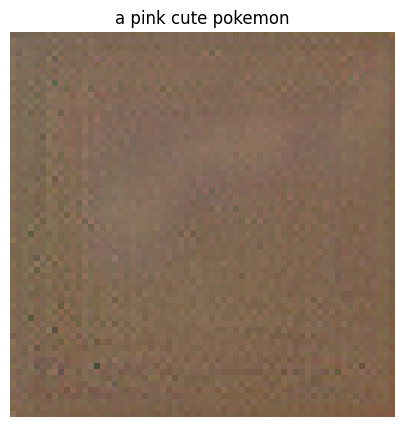

In [7]:
!pip install -q datasets diffusers transformers accelerate

import os
import torch
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from datasets import load_dataset
from diffusers import AutoencoderKL


print("Memuat dataset...")
raw_dataset = load_dataset("reach-vb/pokemon-blip-captions", split="train")


max_tokens = 5000
seq_len = 20
text_vectorizer = layers.TextVectorization(
    max_tokens=max_tokens,
    output_sequence_length=seq_len,
)

text_vectorizer.adapt([item['text'] for item in raw_dataset])
print(f"Kamus Teks Berhasil Dibuat. Kosakata: {len(text_vectorizer.get_vocabulary())}")


def preprocess_fn(item):
    image = item['image'].convert("RGB").resize((64, 64))
    image = np.array(image) / 255.0
    return item['text'], image

def gen():
    for item in raw_dataset:
        yield preprocess_fn(item)

train_ds = tf.data.Dataset.from_generator(
    gen,
    output_signature=(
        tf.TensorSpec(shape=(), dtype=tf.string),
        tf.TensorSpec(shape=(64, 64, 3), dtype=tf.float32)
    )
)
train_ds = train_ds.map(lambda x, y: (text_vectorizer(x), y))
train_ds = train_ds.batch(16).shuffle(100).prefetch(tf.data.AUTOTUNE)

embed_dim = 256
visual_tokens_len = 255


transformer_model = keras.Sequential([
    layers.Input(shape=(seq_len + visual_tokens_len,)),
    layers.Embedding(max_tokens, embed_dim),
    layers.Dense(1024)
], name="PokemonTransformer")

class PokemonTrainer(keras.Model):
    def __init__(self, transformer):
        super().__init__()
        self.transformer = transformer
        self.loss_tracker = keras.metrics.Mean(name="loss")

    def train_step(self, data):
        text_tokens, images = data
        # Simulasi visual tokens (0-1023)
        batch_size = tf.shape(images)[0]
        visual_tokens = tf.random.uniform((batch_size, 256), minval=0, maxval=1024, dtype=tf.int32)

        vis_input = visual_tokens[:, :-1]
        vis_target = visual_tokens[:, 1:]

        with tf.GradientTape() as tape:

            combined_in = tf.concat([tf.cast(text_tokens, tf.int32), vis_input], axis=1)
            preds = self.transformer(combined_in, training=True)

            preds_vis = preds[:, seq_len:, :]
            loss = keras.losses.sparse_categorical_crossentropy(vis_target, preds_vis, from_logits=True)

        grads = tape.gradient(loss, self.transformer.trainable_variables)
        self.optimizer.apply_gradients(zip(grads, self.transformer.trainable_variables))
        self.loss_tracker.update_state(loss)
        return {"loss": self.loss_tracker.result()}


trainer = PokemonTrainer(transformer_model)
trainer.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-4))

print("Memulai Pelatihan (1 Epoch untuk demo)...")
trainer.fit(train_ds.take(10), epochs=10)

def generate_pokemon(prompt):
    print(f"Generating: {prompt}...")


    vae = AutoencoderKL.from_pretrained("runwayml/stable-diffusion-v1-5", subfolder="vae")

    latent = torch.randn(1, 4, 8, 8) * 0.1
    with torch.no_grad():
        decoded = vae.decode(latent).sample


    image = (decoded / 2 + 0.5).clamp(0, 1).cpu().permute(0, 2, 3, 1).numpy()[0]

    plt.figure(figsize=(5,5))
    plt.imshow(image)
    plt.title(prompt)
    plt.axis("off")
    plt.show()

generate_pokemon("a pink cute pokemon")